In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

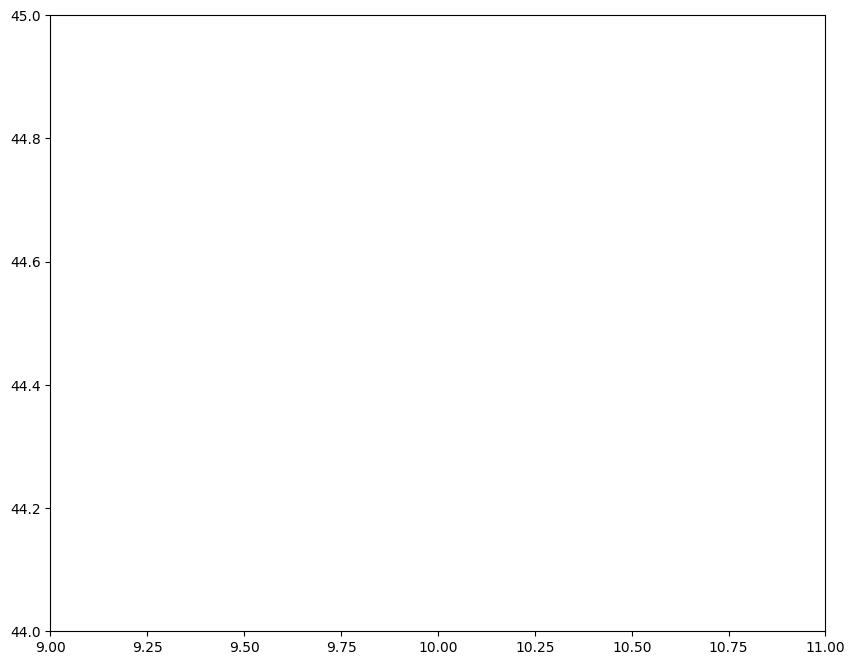

In [29]:
shape = "quasi_circle"

def plot_voronoi(
    shape: str,
):
    df_points = pd.read_csv(f"../data/mesh/{shape}/points.csv").rename(columns={'Unnamed: 0': 'id'})

    _ = plt.figure(figsize=(10, 8))
    _ = plt.scatter(df_points['V1'], df_points['V2'], color='black', s=1)
    id2TriaNodes = {}
    for _, row in df_points.iterrows():
        id2TriaNodes[row['id']] = (row['V1'], row['V2'])

    df_edges = pd.read_csv(f"../data/mesh/{shape}/edges.csv")
    if 'Unnamed: 0' in df_edges.columns:
        df_edges = df_edges.drop(columns='Unnamed: 0')
    triaEdges = []
    for _, row in df_edges.iterrows():
        triaEdges.append([id2TriaNodes[row['V1']], id2TriaNodes[row['V2']]])

    lc = LineCollection(triaEdges, colors='black', linewidths=0.5)

    # Add to current axes
    ax = plt.gca()
    ax.add_collection(lc)

    with open(f"data/{shape}.json", 'r') as f:
        data = json.load(f)

    nodes = data['nodes']

    xs = [item['coords'][0] for item in nodes]
    ys = [item['coords'][1] for item in nodes]

    _ = plt.scatter(xs, ys, s=5, color='red')

    id2Node = {d['id']: (d['coords'][0], d['coords'][1]) for d in nodes}
    data
    edges = [[id2Node[d['from']], id2Node[d['to']]] for d in data['edges']]
    edges

    # lc = LineCollection(edges, colors='red', linewidths=1)

    # Add to current axes
    # ax = plt.gca()
    # ax.add_collection(lc)  
      
    # plt.scatter([0, 0.03125, 0.0625],
    #             [0.9375, 0.96875, 1], s= 10)
    
    # plt.scatter([10.062441180592224], [44.080501886987065], s= 10, color = "green")
    # plt.scatter([7.40772],[44.1215], s=10, color = "green")

    plt.xlim([9, 11])
    plt.ylim([44, 45])
    
    plt.show()

    return data

data = plot_voronoi(shape=shape)

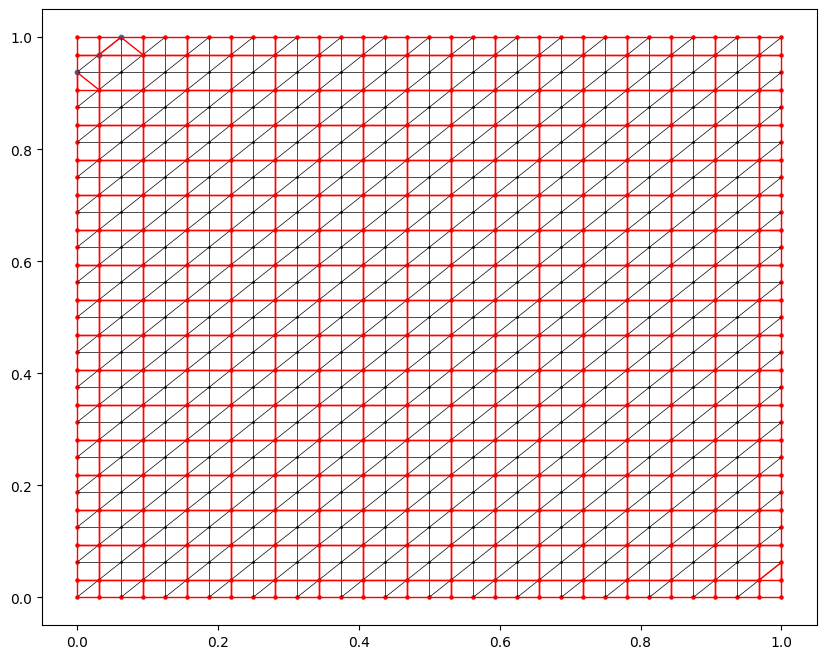

In [28]:
shape = "unit_square_16"
data = plot_voronoi(
    shape=shape
)

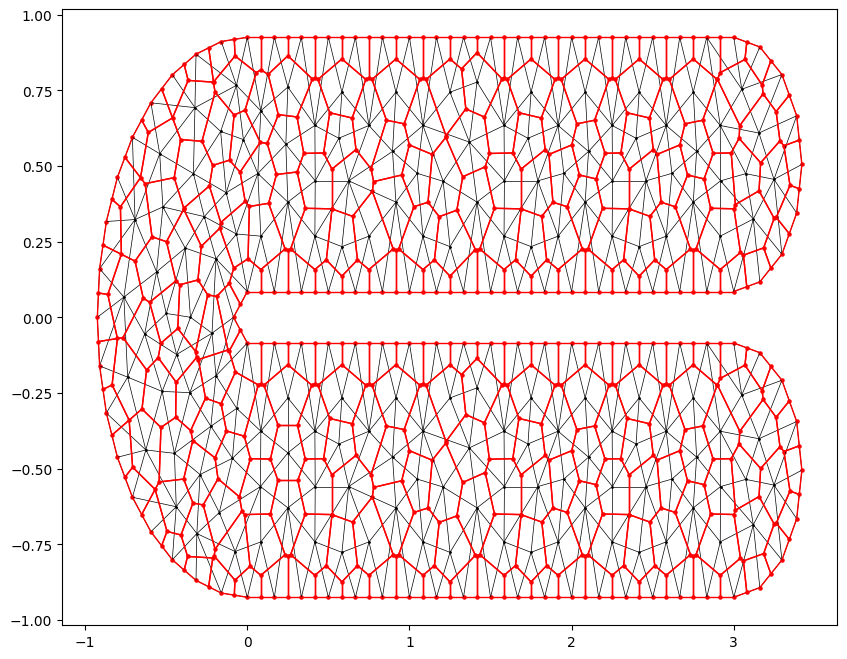

{'cells': [{'edges': [6, 1, 21, 655, 946, 947, 954], 'id': 261},
  {'edges': [5, 951, 12, 7, 1200, 4], 'id': 262},
  {'edges': [3, 1122, 1117, 24, 2], 'id': 196},
  {'edges': [8, 9, 18, 13, 1115], 'id': 125},
  {'edges': [1354, 1351, 1352, 1353, 10, 11], 'id': 99},
  {'edges': [1358, 1355, 1356, 1357, 16, 17], 'id': 98},
  {'edges': [15, 82, 77, 667, 650, 651, 14], 'id': 110},
  {'edges': [22, 23, 648, 643, 1307, 654], 'id': 256},
  {'edges': [1362, 1359, 28, 1360, 1361], 'id': 104},
  {'edges': [27, 31, 43, 940, 936, 26], 'id': 162},
  {'edges': [1366, 1363, 25, 1364, 1365], 'id': 105},
  {'edges': [32, 33, 619, 656, 653, 46], 'id': 161},
  {'edges': [38, 39, 158, 153, 1340, 1341, 1314], 'id': 109},
  {'edges': [37, 1315, 1252, 1253, 42], 'id': 239},
  {'edges': [41, 1268, 608, 609, 1309, 40], 'id': 257},
  {'edges': [45, 1308, 1250, 1245, 956, 44], 'id': 121},
  {'edges': [52, 47, 1120, 1121, 1199, 1116, 652], 'id': 213},
  {'edges': [51, 649, 1144, 1139, 976, 50], 'id': 263},
  {'ed

In [23]:
shape = "c_shaped"
plot_voronoi(
    shape=shape
)

In [26]:
# Let us create the edges.csv file for North Italy
import pandas as pd

# Read triangles
df = pd.read_csv("../data/mesh/north_italy/elements.csv")

# Create edges from each triangle (V1-V2, V2-V3, V3-V1)
edges = pd.concat([
    df[['V1', 'V2']],
    df[['V2', 'V3']].rename(columns={'V2': 'V1', 'V3': 'V2'}),
    df[['V3', 'V1']].rename(columns={'V3': 'V1', 'V1': 'V2'})
], ignore_index=True)

# Save edges
edges.to_csv("../data/mesh/north_italy/edges.csv", index=False)

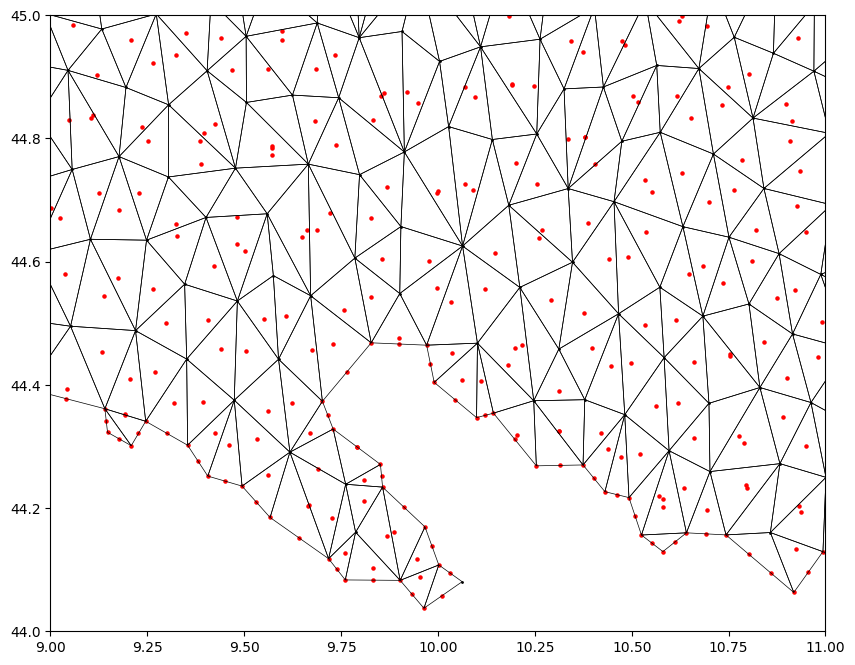

In [30]:
shape = "north_italy"
_ = plot_voronoi(
    shape=shape
)

In [28]:
# Let us create the edges.csv file for North Italy
import pandas as pd

# Read triangles
df = pd.read_csv("../data/mesh/brain/elements.csv")

# Create edges from each triangle (V1-V2, V2-V3, V3-V1)
edges = pd.concat([
    df[['V1', 'V2']],
    df[['V2', 'V3']].rename(columns={'V2': 'V1', 'V3': 'V2'}),
    df[['V3', 'V1']].rename(columns={'V3': 'V1', 'V1': 'V2'})
], ignore_index=True)

# Save edges
edges.to_csv("../data/mesh/brain/edges.csv", index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'data/brain.json'

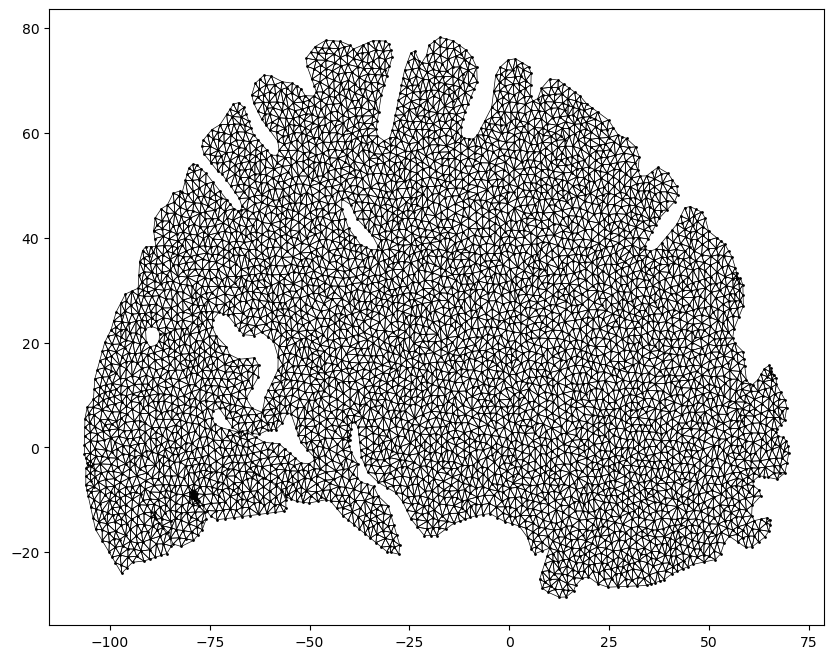

In [29]:
shape = "brain"
_ = plot_voronoi(
    shape=shape
)

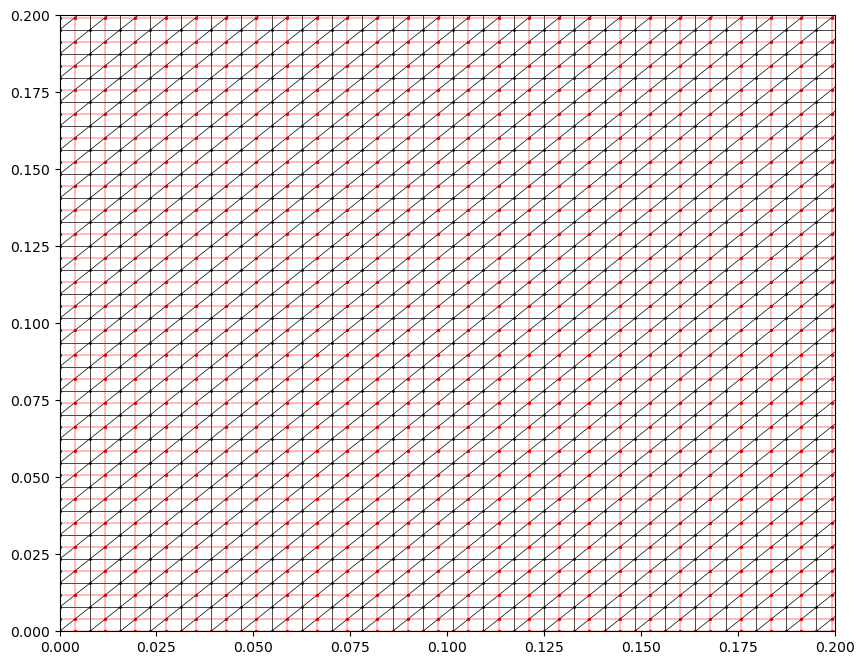

In [ ]:
shape = "unit_square_128"
_ = plot_voronoi(
    shape=shape
)